# CSCI 3151 Assignment 4 - Customer Clustering

**Your Name:** Nora Forghani

**Banner:** B00928800

## Setup

First, let's import the necessary libraries for our analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

## Load Data

We will load the `customer_features.csv` file, which was created by the `create_features.py` script. This dataset contains behavioral information for each customer.

## Dataset Context

This assignment uses the Instacart Market Basket Analysis dataset, which contains real grocery shopping data. The dataset includes information about orders, products, and customer shopping patterns. 

**Performance Note:** We'll work with a sample of 5,000 customers for computational efficiency. Try experimenting with different values.

In [3]:
# Load and sample data for computational efficiency
df_full = pd.read_csv('./data/customer_features.csv')
print(f"Full dataset size: {len(df_full):,} customers")

SAMPLE_SIZE = 5000  
np.random.seed(42)  # Ensure reproducible results, experiment with different seeds

if len(df_full) > SAMPLE_SIZE:
    df = df_full.sample(n=SAMPLE_SIZE, random_state=42)
    print(f"Working with sample of {len(df):,} customers ({len(df)/len(df_full):.1%} of full dataset)")
else:
    df = df_full
    print(f"Using full dataset of {len(df):,} customers")

# Create feature matrix (excluding user_id)
df_features = df.drop('user_id', axis=1)
print(f"\nFeatures: {list(df_features.columns)}")
df_features.head()

Full dataset size: 131,209 customers
Working with sample of 5,000 customers (3.8% of full dataset)

Features: ['total_orders', 'avg_days_between_orders', 'avg_shopping_hour', 'avg_products_per_order', 'department_diversity']


,total_orders,avg_days_between_orders,avg_shopping_hour,avg_products_per_order,department_diversity
115356,7,21.166667,10.000000,1.0,1
66774,5,17.750000,10.600000,30.0,12
108561,63,3.693548,16.587302,16.0,6
125040,55,6.259259,16.309091,11.0,4
66173,6,20.200000,14.666667,16.0,6


# Q1. Understanding the Feature Engineering (2 points)

### 1.1 Feature Engineering Analysis

Before working with the data, it is important to understand how it was created. Examine the `create_features.py` script to understand the feature engineering process.

**In your own words, briefly describe how each of the five features in `customer_features.csv` was calculated and what aspect of customer behavior it is intended to capture:**

1. **total_orders**: Number of completed orders from someone represents how engaged they are with the Instacart platform. It's calculated by counting how many total orders they’ve placed.

2. **avg_days_between_orders**: Shows how often someone shops. It’s calculated by looking at the number of days between each order they place, then averaging that across all their orders.

3. **avg_shopping_hour**: This tells us what time of day someone usually shops. It’s based on the average hour (from 0 to 23) when their orders were placed.

4. **avg_products_per_order**:  This is how many items someone usually buys in one order. It’s calculated by taking the total number of items they bought and dividing by how many orders they’ve made.

5. **department_diversity**: Counts the number of distinct product departments a customer shops from. It shows if they shop from specific categories or a wider variety of categories.


# Q1. Feature Exploration and Scaling (3 points)

### 1.1 Explore Data Distributions

Create histograms for each feature in the `df_features` DataFrame. Describe the shape of each distribution (e.g., skewed right, skewed left, normal). Why is it important to understand feature distributions before clustering?

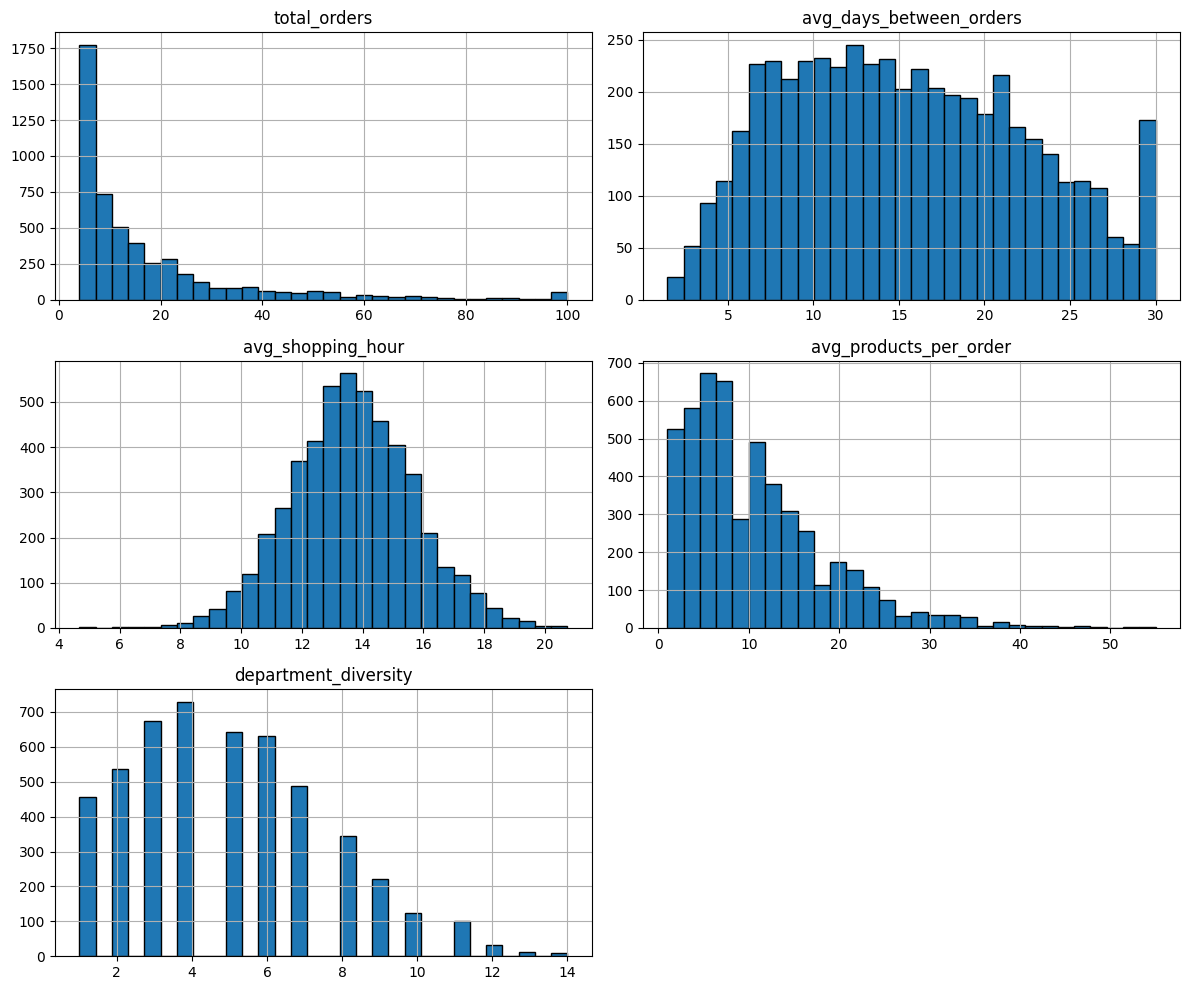

In [6]:
df_features.hist(figsize=(12, 10), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

**Your Answer:**
- total_orders: Right skewed. 
- avg_days_between_orders: Slight right skewed.
- avg_shopping_hour: Normal.
- avg_products_per_order: Right skewed.
- department_diversity: Right skewed.


### 1.2 The Need for Scaling

The features in the dataset have very different scales (e.g., `total_orders` vs. `avg_shopping_hour`). Explain why this is a problem for K-means, which relies on  Euclidean distance.


**Your Answer:**
Since K-Means uses Euclidean distance to determine which data points belong together in the same cluster, it will always heavily favour high range features like total_orders ignoring small differences in low range features like shopping_hour. This is an issue because it will result in a cluster being based entirely on one feature instead of taking all features into consideration.

### 1.3 Apply Feature Scaling

Scale the features using `StandardScaler`. Create histograms of the scaled features. How have the distributions changed after scaling? What are the new mean and standard deviation of the scaled features?

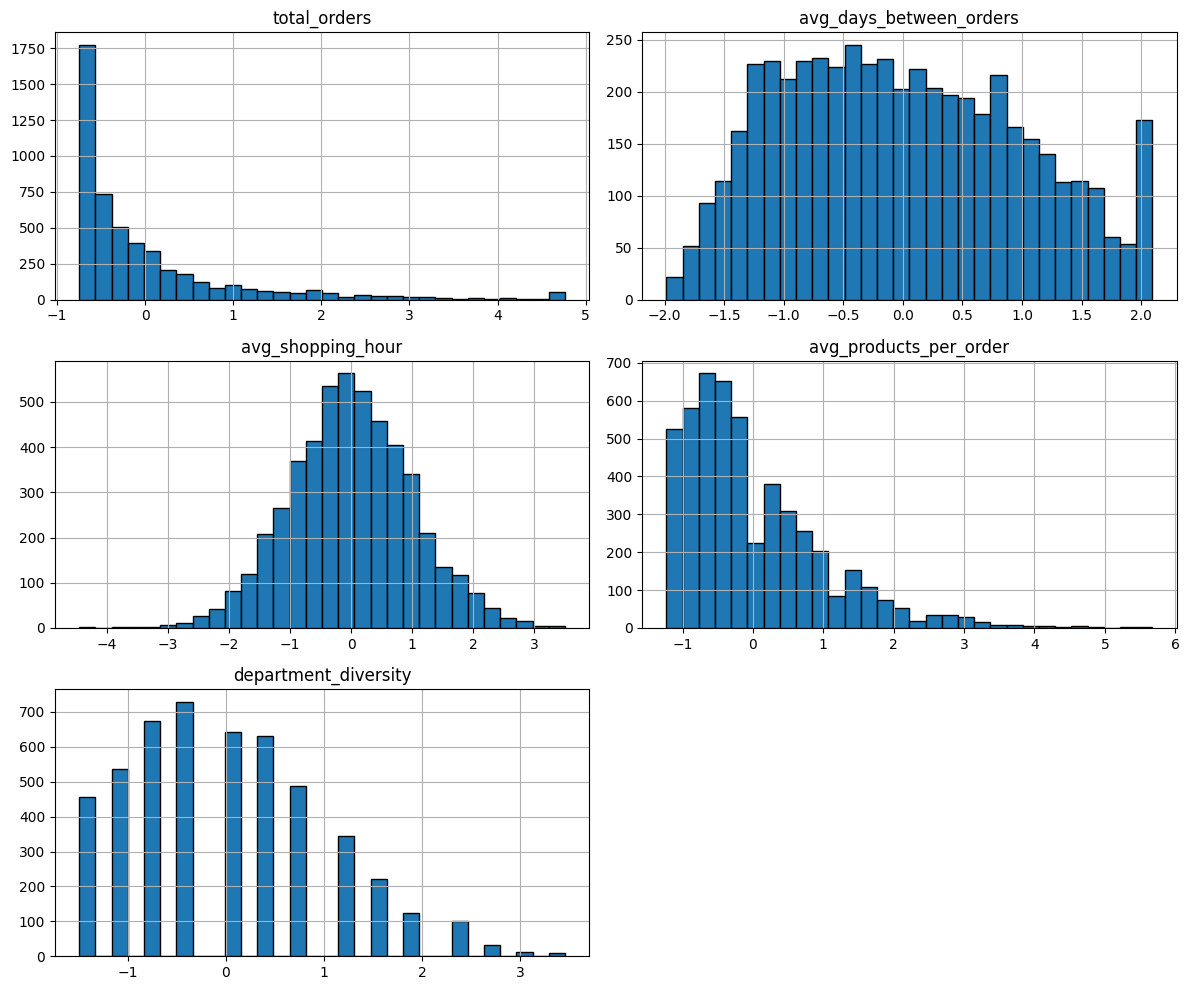

Scaled Feature Statistics:
      total_orders  avg_days_between_orders  avg_shopping_hour  \
mean -8.668621e-17            -3.467449e-16       1.467981e-15   
std   1.000100e+00             1.000100e+00       1.000100e+00   

      avg_products_per_order  department_diversity  
mean            4.760636e-17          1.143974e-16  
std             1.000100e+00          1.000100e+00  


In [7]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(df_features)

# Create a DataFrame for the scaled features for easier plotting
df_scaled = pd.DataFrame(features_scaled, columns=df_features.columns)

# Plot histograms of scaled features
df_scaled.hist(figsize=(12, 10), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

# Display the mean and standard deviation of the scaled features
print("Scaled Feature Statistics:")
print(df_scaled.describe().loc[['mean', 'std']])

**Your Answer:**
- The values on the x-axis of all histograms have changed while the shape [distributions] remained the same. We have made sure that no single feature dominates clustering just because it has a way larger vallue. This is because all features now have the same range and contribute equally to clustering.
- All features now have mean close to 0 and standard deviation close to 1 which was the goal of standardization.

# Q2. K-Means Clustering (4 points)

### 2.1 The Elbow Method

Explain how the Elbow Method helps determine the optimal number of clusters (k). Plot the Within-Cluster Sum of Squares (WCSS) for k values from 1 to 10. Based on your plot, what is a reasonable value for k? Justify your choice.

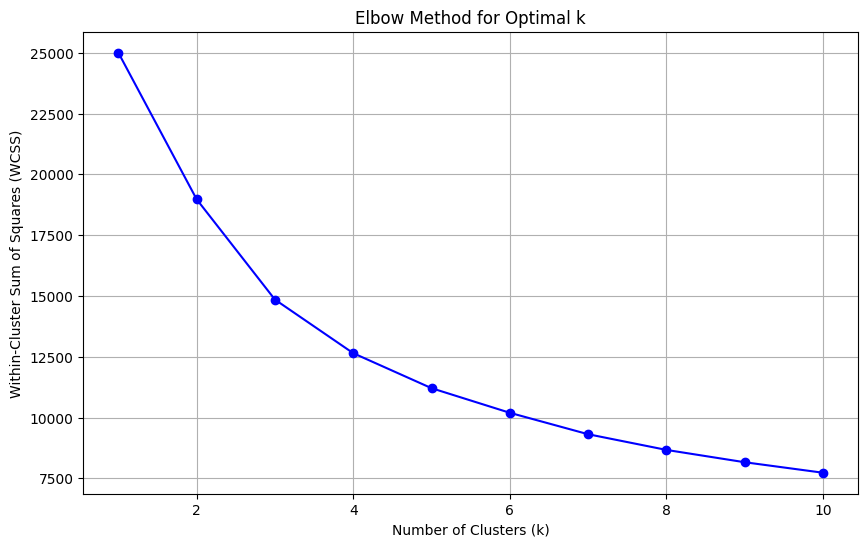

In [8]:
wcss = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_values, wcss, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

Computing optimal k (this may take 30-60 seconds)...
k=1 completed
k=2 completed
k=3 completed
k=4 completed
k=5 completed
k=6 completed
k=7 completed


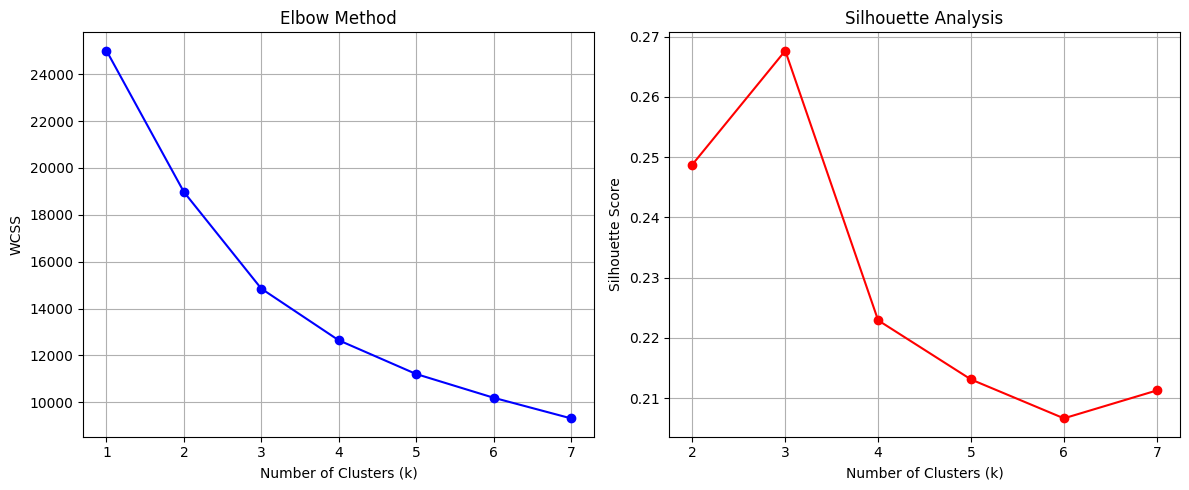


Completed in 1.3 seconds

Silhouette Scores:
k=2: 0.249
k=3: 0.268
k=4: 0.223
k=5: 0.213
k=6: 0.207
k=7: 0.211

Best silhouette score at k=3


In [9]:
# Optimized Elbow Method and Silhouette Analysis
import time
start_time = time.time()

wcss = []
silhouette_scores = []

# Optimize KMeans parameters for speed
print("Computing optimal k (this may take 30-60 seconds)...")

for k in range(1, 8):  # Reduced range - rarely need more than 7 clusters
    # Faster KMeans settings for student laptops
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=100)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)
    
    # Calculate silhouette score (only for k>=2)
    if k >= 2:
        score = silhouette_score(df_scaled, kmeans.labels_)
        silhouette_scores.append(score)
    
    print(f"k={k} completed")

# Create plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Elbow Method plot
ax1.plot(range(1, 8), wcss, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS')
ax1.set_title('Elbow Method')
ax1.grid(True)

# Silhouette Analysis plot
ax2.plot(range(2, 8), silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Print results
print(f"\nCompleted in {time.time() - start_time:.1f} seconds")
print("\nSilhouette Scores:")
for i, score in enumerate(silhouette_scores, 2):
    print(f"k={i}: {score:.3f}")
    
best_k = silhouette_scores.index(max(silhouette_scores)) + 2
print(f"\nBest silhouette score at k={best_k}")

**Your Answer:**
- WCSS shows how far each point is from its clusters center. The lower WCSS the tighter the clusters which is the goal. WCSS decreases as the number of clusters go up until you hit a point where adding more clusters doesn't help anymore. The "elbow" is where WCSS starts to flatten ot after it's dropped steeply. This happens at k=3. The Silhouette score also confirms that k=3 is the best choice since  it has the highest score. The closer the Silhouette Score is to 1 the better the clustering. So based on both methods k=3 is optimal.

### 2.2 Perform Clustering

Run K-means clustering on the scaled data using your chosen value of k. Add the resulting cluster labels back to the original `df` DataFrame.

In [11]:
# Perform final clustering with optimized settings
optimal_k = 3

# Use faster settings for final clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=5, max_iter=100)
cluster_labels = kmeans.fit_predict(df_scaled)

# Add cluster labels to the original DataFrame
df['cluster'] = cluster_labels

print(f"Successfully assigned {len(df)} customers to {optimal_k} clusters.")
print(f"Cluster distribution: {df['cluster'].value_counts().sort_index().to_dict()}")
df.head()

Successfully assigned 5000 customers to 3 clusters.
Cluster distribution: {0: 1507, 1: 2774, 2: 719}


,user_id,total_orders,avg_days_between_orders,avg_shopping_hour,avg_products_per_order,department_diversity,cluster
115356,181364,7,21.166667,10.000000,1.0,1,1
66774,104990,5,17.750000,10.600000,30.0,12,0
108561,170705,63,3.693548,16.587302,16.0,6,2
125040,196458,55,6.259259,16.309091,11.0,4,2
66173,104038,6,20.200000,14.666667,16.0,6,0


### 2.3 Analyze Cluster Centers

Examine the cluster centers (centroids). To make them interpretable, analyze the mean feature values for each cluster in their **original scale**. Describe what each cluster represents in terms of customer behavior. For example, does a cluster represent 'high-spending, frequent shoppers' or 'new, infrequent customers'?

In [12]:
# Group by cluster and calculate the mean of the features (in original scale)
cluster_summary = df.groupby('cluster').mean()
cluster_summary.drop('user_id', axis=1, inplace=True)

print("Cluster Characteristics (Mean Values):")
cluster_summary

Cluster Characteristics (Mean Values):


,total_orders,avg_days_between_orders,avg_shopping_hour,avg_products_per_order,department_diversity
cluster,,,,,
0,12.996682,16.180725,13.890976,19.215660,7.864632
1,10.356525,17.152622,13.662340,6.182408,3.410598
2,51.144645,6.687580,13.223850,9.728790,4.611961


**Your Answer:**
- Cluster 0: medium active shoppers, large and varied orders every few weeks.
- Cluster 1: infrequent, light, likely newer shoppers.
- Cluster 2: very active and frequent shoppers. [shop regularly from more specific departments]

# Q3. Analysis and Interpretation (3 points)

### 3.1 Visualize Clusters

Create a scatter plot of two features (e.g., `total_orders` vs. `avg_products_per_order`), coloring the points by their assigned cluster. Do the clusters appear well-separated?

Creating visualizations...


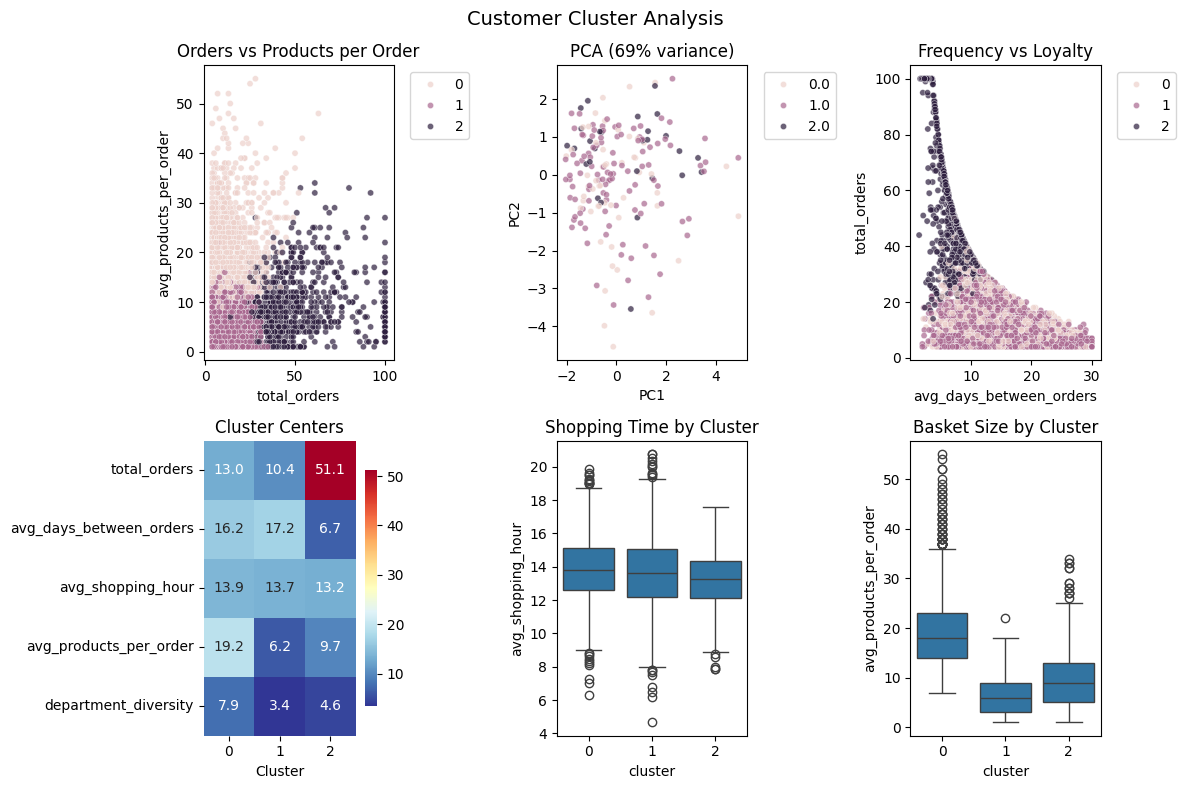


Key Insights:
• PCA captures 69% of variance in 2D
• Sample size: 5000 customers 
• Cluster sizes: {0: np.int64(1507), 1: np.int64(2774), 2: np.int64(719)}


In [13]:
# Efficient Cluster Visualization Analysis
print("Creating visualizations...")

# Set up the plotting area (reduced size for faster rendering)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Customer Cluster Analysis', fontsize=14)

# 1. Original scatter plot
sns.scatterplot(data=df, x='total_orders', y='avg_products_per_order', 
                hue='cluster', ax=axes[0,0], alpha=0.7, s=20)
axes[0,0].set_title('Orders vs Products per Order')
axes[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 2. PCA projection (reduce 5D to 2D)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
df_pca['cluster'] = df['cluster']

sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='cluster', ax=axes[0,1], alpha=0.7, s=20)
axes[0,1].set_title(f'PCA ({pca.explained_variance_ratio_.sum():.0%} variance)')
axes[0,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 3. Shopping frequency vs loyalty
sns.scatterplot(data=df, x='avg_days_between_orders', y='total_orders', 
                hue='cluster', ax=axes[0,2], alpha=0.7, s=20)
axes[0,2].set_title('Frequency vs Loyalty')
axes[0,2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. Cluster centers heatmap
cluster_centers = df.groupby('cluster')[['total_orders', 'avg_days_between_orders', 
                                        'avg_shopping_hour', 'avg_products_per_order', 
                                        'department_diversity']].mean()

sns.heatmap(cluster_centers.T, annot=True, cmap='RdYlBu_r', ax=axes[1,0], 
            fmt='.1f', cbar_kws={'shrink': 0.8})
axes[1,0].set_title('Cluster Centers')
axes[1,0].set_xlabel('Cluster')

# 5. Shopping time patterns
sns.boxplot(data=df, x='cluster', y='avg_shopping_hour', ax=axes[1,1])
axes[1,1].set_title('Shopping Time by Cluster')

# 6. Basket size patterns  
sns.boxplot(data=df, x='cluster', y='avg_products_per_order', ax=axes[1,2])
axes[1,2].set_title('Basket Size by Cluster')

plt.tight_layout()
plt.show()

# Print key insights
print("\nKey Insights:")
print(f"• PCA captures {pca.explained_variance_ratio_.sum():.0%} of variance in 2D")
print(f"• Sample size: {len(df)} customers ")
print(f"• Cluster sizes: {dict(df['cluster'].value_counts().sort_index())}")

**Your Answer:**
The clusters are fairly well separated
- Cluster 2 stands out clearly with high total orders.
- Clusters 0 and 1 overlap more, since their order counts and order sizes are closer together
The plot shows that these two features do capture some meaningful differences in behavior between customer types but don't seperate clusters perfectly.

### 3.2 Ethical Considerations

Customer clustering is a powerful tool for businesses, but it can have ethical implications. Discuss one potential benefit and one potential harm of using this type of analysis.

**Your Answer:** 
- Benefit: allows businesses to adjust marketing and product recommendations based on the shopping habits of customers. For example loyal shoppers can be rewarded with special offers and infrequent shoppers can be sent reminders to use Instacart more often.
- Harm: Can lead to exclusion if used poorly. There may be a risk of biases against a certain cluster of customers by reinforcing economic or demographic patterns. 


### 3.3 Limitations of K-Means

What is one key limitation of the K-means algorithm? For instance, what assumptions does it make about the shape of the clusters?

**Your Answer:**

- It assumes all clusters are equal in size and spherical in shape. This means it works best when the groups in the data are roughly circular and similar in density. If the real clusters are irregularly shaped or different sizes k-means can produce poor results. 
- It can also struggle with overlapping clusters  [outliers] since it assigns each point to the nearest cluster center based on euclidean distance.